ELECTRE TRI-B REGIÃO METROPOLITANA PARÁ

In [ ]:
!pip install pyDecision

##PRE PROCESSING

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from pyDecision.algorithm import electre_tri_b

In [28]:
df = pd.read_csv('https://raw.githubusercontent.com/AlanaMiranda/Classification-RMBPA/refs/heads/main/df_criterios.csv', sep = ',')

In [29]:
df

,MUNICIPIO,IAP,IDH,PIB,Desemprego,Alfabetizacao,RMD,PPBR,SMM
0,BELEM,3.0,746,22216.33,10.07,97.05,812.43,39.64,3.6
1,ANANINDEUA,3.0,718,16542.68,10.98,97.20,544.31,52.16,1.9
2,CASTANHAL,4.0,673,22897.75,9.52,94.12,449.32,36.23,1.8
3,BARCARENA,5.0,662,71473.92,13.11,93.85,416.77,52.32,2.7
4,SANTA IZABEL DO PARA,0.0,659,12835.31,10.09,92.91,377.73,50.34,1.7
5,BENEVIDES,1.5,665,30668.86,13.60,94.44,375.51,47.25,2.0
6,MARITUBA,2.0,676,18986.11,14.44,95.61,366.44,67.50,2.1
7,SANTA BARBARA DO PARA,0.5,627,11027.66,11.45,91.84,276.46,55.35,1.6


In [8]:
x = df[['IAP','IDH','PIB','Alfabetizacao','SMM']]

In [9]:
x.describe()

,IAP,IDH,PIB,Alfabetizacao,SMM
count,8.000000,8.000000,8.000000,8.000000,8.000000
mean,2.375000,678.250000,25831.077500,94.627500,2.175000
std,1.706082,37.108913,19455.087735,1.892419,0.667083
min,0.000000,627.000000,11027.660000,91.840000,1.600000
25%,1.250000,661.250000,15615.837500,93.615000,1.775000
50%,2.500000,669.000000,20601.220000,94.280000,1.950000
75%,3.250000,686.500000,24840.527500,95.970000,2.250000
max,5.000000,746.000000,71473.920000,97.200000,3.600000


In [10]:
columns_to_scale = x
scaler = MinMaxScaler(feature_range=(0,1))

for i in columns_to_scale:
    x[i] = scaler.fit_transform(x[[i]])

<ipython-input-10-c83692767b1c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[i] = scaler.fit_transform(x[[i]])
<ipython-input-10-c83692767b1c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[i] = scaler.fit_transform(x[[i]])
<ipython-input-10-c83692767b1c>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/

In [11]:
x.dtypes

,0
IAP,float64
IDH,float64
PIB,float64
Alfabetizacao,float64
SMM,float64


##QUARTIS

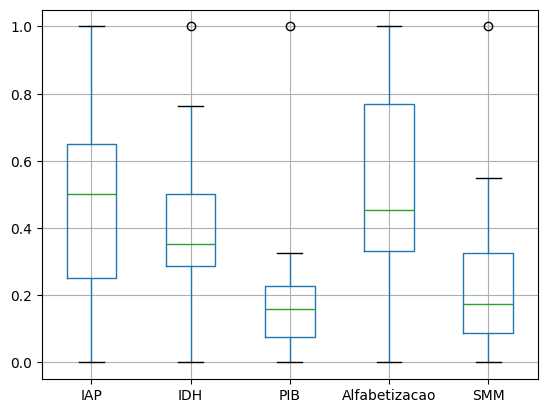

array([[0.25      , 0.28781513, 0.07590507, 0.33115672, 0.0875    ],
       [0.5       , 0.35294118, 0.15838135, 0.45522388, 0.175     ],
       [0.65      , 0.5       , 0.22851484, 0.77052239, 0.325     ]])

In [12]:
import matplotlib.pyplot as plt

def create_boxplot(dataset):

    Q3 = np.quantile(dataset, 0.75)
    Q1 = np.quantile(dataset, 0.25)
    MEDIAN = np.quantile(dataset, 0.50)
    IQR = Q3 - Q1

    lower_range = Q1 - 0.15 * IQR
    upper_range = Q3 + 0.15 * IQR

    while lower_range < 0:
        dst = dataset[dataset[dataset.columns[0]] > Q1]

        Q3 = np.quantile(dst, 0.75)
        Q1 = np.quantile(dst, 0.25)
        MEDIAN = np.quantile(dst, 0.50)
        IQR = Q3 - Q1

        lower_range = Q1 - 0.15 * IQR
        upper_range = Q3 + 0.15 * IQR

        dataset = dst

    print(f"Q3 = {Q3}")
    print(f"Q1 = {Q1}")
    print(f"IQR = {IQR}")
    print(f"Median = {MEDIAN}")
    print(f"Lower_Range = {lower_range}")
    print(f"Upper_Range = {upper_range}")


def print_limits(dataset) -> np.array:

    res = np.zeros((3, 5))

    #boxplot create
    _, bp = pd.DataFrame.boxplot(dataset, return_type='both')
    caps = [cap.get_ydata() for cap in bp["caps"]] # limites inferior e superior
    outliers = [flier.get_ydata() for flier in bp["fliers"]]  # Desconsiderar
    boxes = [box.get_ydata() for box in bp["boxes"]] # Q1 e Q3
    medians = [median.get_ydata() for median in bp["medians"]] # Mediana
    whiskers = [whiskers.get_ydata() for whiskers in bp["whiskers"]] # Q1 Q3 LimSup LimInf
    plt.show()

    #print(f"caps: {caps}")
    #print(f"outliers: {outliers}")
    #print(f"boxes: {boxes}")
    #print(f"medians: {medians}")
    #print(f"whiskers: {whiskers}")


    cont = 0
    for c in range(0, len(whiskers), 2):
        lower_range = whiskers[c][1]

        Q1 = whiskers[c][0]
        M = medians[cont][0]
        Q3 = whiskers[c+1][0]

        upper_range = whiskers[c+1][1]


        # res[0][cont] = lower_range
        # res[1][cont] = Q1
        # res[2][cont] = M
        # res[3][cont] = Q3
        # res[4][cont] = upper_range

        # res[0][cont] = Q1
        # res[1][cont] = M
        # res[2][cont] = Q3
        # res[3][cont] = upper_range

        res[0][cont] = Q1
        res[1][cont] = M
        res[2][cont] = Q3


        cont += 1


    return res


print_limits(x)

##AHP WEIGHT DEFINITION

In [13]:
from pyDecision.algorithm import ahp_method

In [14]:
weight_derivation = 'geometric' # 'mean'; 'geometric' or 'max_eigen'

# Dataset
dataset = np.array([
       #IAP     IDH     PIB     ALFA     SMM
  [1  ,     5,     2,        2  ,   2],   #IAP
  [1/5  ,   1  ,   1/3,      1/3  ,   1/3],   #IDH
  [1/2  ,   3,     1  ,      1  ,   1],   #PIB
  [1/2  ,  3,     1,        1  ,   1],   #ALFA
  [1/2  ,    3,   1,       1  ,   1]  #SMM
])

# Call AHP Function
weights, rc = ahp_method(dataset, wd = weight_derivation)

# Weigths
for i in range(0, weights.shape[0]):
  print('w(g'+str(i+1)+'): ', round(weights[i], 3))

# Consistency Ratio
print('RC: ' + str(round(rc, 2)))
if (rc > 0.10):
  print('The solution is inconsistent, the pairwise comparisons must be reviewed')
else:
  print('The solution is consistent')

w(g1):  0.366
w(g2):  0.066
w(g3):  0.19
w(g4):  0.19
w(g5):  0.19
RC: 0.0
The solution is consistent


##ELECTRE TRI B

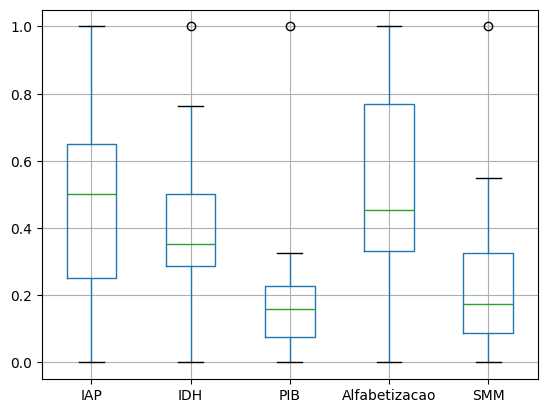

array([[0.25      , 0.28781513, 0.07590507, 0.33115672, 0.0875    ],
       [0.5       , 0.35294118, 0.15838135, 0.45522388, 0.175     ],
       [0.65      , 0.5       , 0.22851484, 0.77052239, 0.325     ]])

In [15]:
Q = [0.1,      0.1,       0.1,     0.1,     0.1]
P = [0.2,      0.2,       0.2,     0.2,     0.2]
V = [1.0,      1.0,       1.0,     1.0,     1.0]
W = [36.6,    6.6,      19.0,    19.0,    19.0]
B = print_limits(x).tolist()

np.array(B)

In [16]:
import matplotlib.patches as mpatches
import copy
from sklearn.decomposition import TruncatedSVD


def plot_points(data, classification):
    plt.style.use('ggplot')
    #colors = {'A':'#54FF00', 'B':'#FFEB00', 'C':'#FF9500', 'D':'#FF0000', 'E':'#FF0000', 'F':'#ff796c', 'G':'#04d8b2', 'H':'#ffb07c', 'I':'#aaa662', 'J':'#0485d1', 'K':'#fffe7a', 'L':'#b0dd16', 'M':'#85679', 'N':'#12e193', 'O':'#82cafc', 'P':'#ac9362', 'Q':'#f8481c', 'R':'#c292a1', 'S':'#c0fa8b', 'T':'#ca7b80', 'U':'#f4d054', 'V':'#fbdd7e', 'W':'#ffff7e', 'X':'#cd7584', 'Y':'#f9bc08', 'Z':'#c7c10c'}
    colors = {'A':'#FFFFCC', 'B':'#FEBF5A', 'C':'#F43D25', 'D':'#800026'}
    classification_ = copy.deepcopy(classification)
    color_leg = {}
    if (data.shape[1] == 2):
        data_proj = np.copy(data)
    else:
        tSVD      = TruncatedSVD(n_components = 2, n_iter = 100, random_state = 42)
        tSVD_proj = tSVD.fit_transform(data)
        data_proj = np.copy(tSVD_proj)
        #variance  = sum(np.var(tSVD_proj, axis = 0) / np.var(tSVD_proj, axis = 0).sum())
    class_list  = list(set(classification_))
    for i in range(0, len(classification_)):
        classification_[i] = str(classification_[i])
    for i in range(0, len(classification_)):
        for j in range(0, len(class_list)):
            classification_[i] = classification_[i].replace(str(class_list[j]), str(chr(ord('A') + class_list[j])))
    class_list = list(set(classification_))
    class_list.sort()
    for i in range(0, len(class_list)):
        color_leg[class_list[i]] = colors[class_list[i]]
    patchList = []
    for key in color_leg:
        data_key = mpatches.Patch(color = color_leg[key], label = key)
        patchList.append(data_key)
    for i in range(0, data_proj.shape[0]):
        plt.text(data_proj[i, 0], data_proj[i, 1], 'x' + str(i+1), size = 10, ha = 'center', va = 'center', bbox = dict(boxstyle = 'round', ec = (0.0, 0.0, 0.0), fc = colors[classification_[i]],))
    plt.gca().legend(handles = patchList, loc = 'center left', bbox_to_anchor = (1.05, 0.5))
    axes = plt.gca()
    xmin = np.amin(data_proj[:,0])
    xmax = np.amax(data_proj[:,0])
    #axes.set_xlim([xmin*0.7, xmax*1])
    axes.set_xlim([xmin, xmax*1])
    ymin = np.amin(data_proj[:,1])
    ymax = np.amax(data_proj[:,1])
    if (ymin < ymax):
        axes.set_ylim([ymin, ymax])
    else:
        axes.set_ylim([ymin*0.7, ymax*1])
    plt.show()

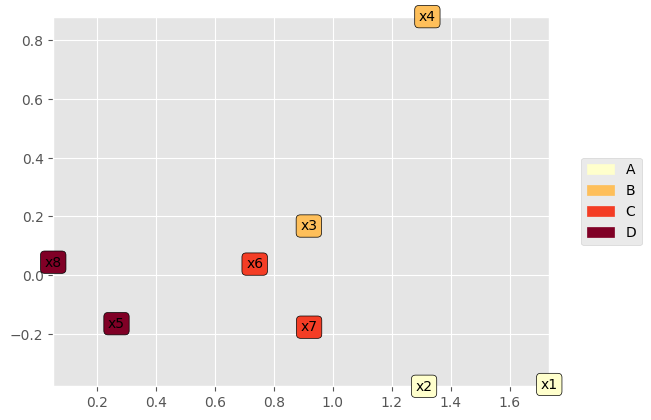

In [17]:
classification = electre_tri_b(np.array(x), W , Q , P , V , B, cut_level = 0.75, verbose = False, rule = 'pc', graph = False)

plot_points(np.array(x), classification)

In [18]:
# Classification
for i in range(0, len(classification)):
  print('x'+str(i+1)+': '+' Class: '+str(classification[i]))

x1:  Class: 0
x2:  Class: 0
x3:  Class: 1
x4:  Class: 1
x5:  Class: 3
x6:  Class: 2
x7:  Class: 2
x8:  Class: 3


In [19]:
#Criando um rank das alternativas de acordo com os pesos
scores = np.dot(x, W)

# Combinar as categorias e escores para ranking
ranked_alternatives = sorted(
    enumerate(classification),
    key=lambda x: (x[1], scores[x[0]]),
    reverse=True
)

# Exibir os resultados do ranking
print("Ranking das Alternativas:")
for rank, (idx, category) in enumerate(ranked_alternatives):
    print(f'Rank {rank+1}: Alternativa {idx+1} está na Categoria {category} com escore {scores[idx]:.2f}')

Ranking das Alternativas:
Rank 1: Alternativa 5 está na Categoria 3 com escore 7.09
Rank 2: Alternativa 8 está na Categoria 3 com escore 3.66
Rank 3: Alternativa 7 está na Categoria 2 com escore 37.97
Rank 4: Alternativa 6 está na Categoria 2 com escore 32.28
Rank 5: Alternativa 4 está na Categoria 1 com escore 75.12
Rank 6: Alternativa 3 está na Categoria 1 com escore 45.54
Rank 7: Alternativa 1 está na Categoria 0 com escore 69.55
Rank 8: Alternativa 2 está na Categoria 0 com escore 50.59


In [20]:
df['CLASS'] = classification
df['id'] = ['1501402', '1500800', '1502400', '1501303', '1506500', '1501501', '1504422', '1506351']

<ipython-input-20-3a5e63c0a204>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['CLASS'] = classification
<ipython-input-20-3a5e63c0a204>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['id'] = ['1501402', '1500800', '1502400', '1501303', '1506500', '1501501', '1504422', '1506351']


In [21]:
df_munic = df[['id', 'MUNICIPIO', 'IAP', 'IDH', 'PIB', 'Alfabetizacao', 'SMM', 'CLASS']]
df_munic

,id,MUNICIPIO,IAP,IDH,PIB,Alfabetizacao,SMM,CLASS
0,1501402,BELEM,3.0,746,22216.33,97.05,3.6,0
1,1500800,ANANINDEUA,3.0,718,16542.68,97.20,1.9,0
2,1502400,CASTANHAL,4.0,673,22897.75,94.12,1.8,1
3,1501303,BARCARENA,5.0,662,71473.92,93.85,2.7,1
4,1506500,SANTA IZABEL DO PARA,0.0,659,12835.31,92.91,1.7,3
5,1501501,BENEVIDES,1.5,665,30668.86,94.44,2.0,2
6,1504422,MARITUBA,2.0,676,18986.11,95.61,2.1,2
7,1506351,SANTA BARBARA DO PARA,0.5,627,11027.66,91.84,1.6,3


##MAPA

In [22]:
!pip install geopandas

In [30]:
import geopandas as gpd
gdf_munic = gpd.read_file('https://raw.githubusercontent.com/AlanaMiranda/Classification-RMBPA/refs/heads/main/geojs-15-mun.json')

#gdf_munic.head()
for value in gdf_munic['id']:
    gdf_munic['id'].replace(to_replace=value, value=value, regex=True,inplace=True)


df_teste = pd.merge(df_munic, gdf_munic, on='id', how='left')

df_teste = df_teste[['id', 'MUNICIPIO', 'geometry','IAP','IDH', 'PIB', 'Alfabetizacao', 'SMM']]

df_teste['classe'] = classification

<ipython-input-30-ce4dcbd01666>:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  gdf_munic['id'].replace(to_replace=value, value=value, regex=True,inplace=True)


In [24]:
df_teste

,id,MUNICIPIO,geometry,IAP,IDH,PIB,Alfabetizacao,SMM,classe
0,1501402,BELEM,"POLYGON ((-48.35261 -1.22067, -48.36509 -1.229...",3.0,746,22216.33,97.05,3.6,0
1,1500800,ANANINDEUA,"POLYGON ((-48.33423 -1.23948, -48.33536 -1.249...",3.0,718,16542.68,97.20,1.9,0
2,1502400,CASTANHAL,"POLYGON ((-47.87064 -1.06049, -47.85322 -1.064...",4.0,673,22897.75,94.12,1.8,1
3,1501303,BARCARENA,"POLYGON ((-48.48154 -1.56796, -48.45616 -1.620...",5.0,662,71473.92,93.85,2.7,1
4,1506500,SANTA IZABEL DO PARA,"POLYGON ((-48.09105 -1.19437, -48.0853 -1.2062...",0.0,659,12835.31,92.91,1.7,3
5,1501501,BENEVIDES,"POLYGON ((-48.33536 -1.24999, -48.33123 -1.256...",1.5,665,30668.86,94.44,2.0,2
6,1504422,MARITUBA,"POLYGON ((-48.28458 -1.43624, -48.29259 -1.470...",2.0,676,18986.11,95.61,2.1,2
7,1506351,SANTA BARBARA DO PARA,"POLYGON ((-48.22756 -1.10625, -48.22412 -1.112...",0.5,627,11027.66,91.84,1.6,3


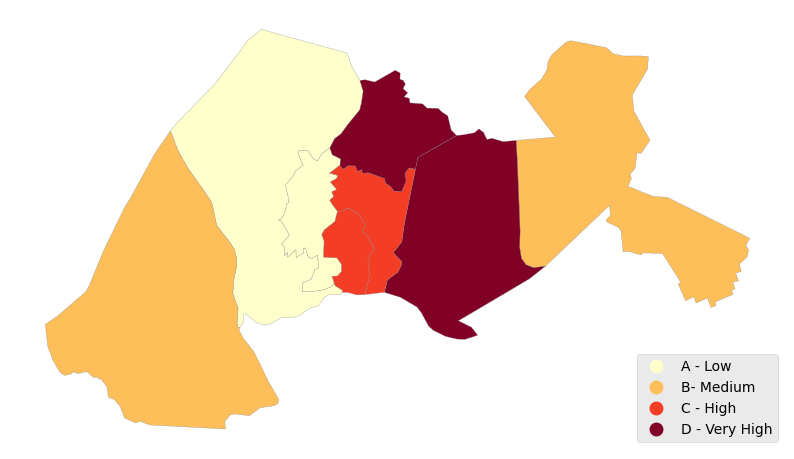

In [25]:
clusdict={1: 'B- Medium', 2: 'C - High', 3: 'D - Very High', 0: 'A - Low' }
df_teste['legend'] = df_teste['classe'].map(clusdict)
df_teste['classe'] = classification

gpd_teste = gpd.GeoDataFrame(df_teste)

ax = gpd_teste.plot(column='legend', categorical=True, legend=True, legend_kwds={'loc': 'lower right'}, figsize=(10,10), cmap='YlOrRd', edgecolor='grey', linewidth = 0.20)

def replace_legend_items(legend, mapping):
    for txt in legend.texts:
        for k,v in mapping.items():
            if txt.get_text() == str(k):
                txt.set_text(v)

replace_legend_items(ax.get_legend(), clusdict)

ax.set_axis_off()


In [26]:
!pip install folium matplotlib mapclassify

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.1/59.1 kB 2.6 MB/s eta 0:00:00


In [27]:
m = gpd_teste.explore(column='legend', cmap='YlOrRd',tooltip=False, popup=['MUNICIPIO', 'legend','IAP','IDH', 'PIB', 'Alfabetizacao', 'SMM'], style_kwds=dict(color="black",weight=1, opacity=0.4))

m.save("mapa_interativo.html")